# SEMANA 9: REDES NEURONALES ARTIFICIALES

## 1.  En esta ocasión se hará la implementación de una red neuronal de clasificación y otra red neuronal convolucional, tomando un 20% de datos de prueba para ambos casos:

### a.  Mediante la base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository y utilizando la librería de Python ‘scikit-learn’, cree una red neuronal para clasificar a un paciente como canceroso o no canceroso de tal forma que obtenga el mayor valor de accuracy. Para ello, debe realizar el preprocesamiento de la información e ir ajustando la red neuronal con los parámetros requeridos como la cantidad de capas ocultas y neuronas por cada capa oculta, el número de iteraciones, la función de activación, el método para minimizar la función de error, entre otros.

In [2]:
import pandas as pd
df=pd.read_csv("cancer.csv")
df

,Unnamed: 0,ClumpThick,UnifCellSize,UnifCellShape,MargAdh,SingEpiCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses,Class
0,0,5,1,1,1,2,1,3,1,1,0
1,1,5,4,4,5,7,10,3,2,1,0
2,2,3,1,1,1,2,2,3,1,1,0
3,3,6,8,8,1,3,4,3,7,1,0
4,4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,694,3,1,1,1,3,2,1,1,1,0
695,695,2,1,1,1,2,1,1,1,1,0
696,696,5,10,10,3,7,3,8,10,2,1
697,697,4,8,6,4,3,4,10,6,1,1


In [4]:
# Eliminar la columna Unnamed: 0,ya que no es relevante
df = df.drop(columns=['Unnamed: 0'])

# Verificar si hay valores nulos en el DataFrame
df.isnull().sum()


ClumpThick         0
UnifCellSize       0
UnifCellShape      0
MargAdh            0
SingEpiCellSize    0
BareNuclei         0
BlandChromatin     0
NormalNucleoli     0
Mitoses            0
Class              0
dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Separar las características (X) y la variable objetivo (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Escalar las características para que todas tengan la misma magnitud
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [10]:
# Definir la red neuronal (MLPClassifier)
# Comenzamos con 2 capas ocultas, cada una con 10 neuronas
model = MLPClassifier(hidden_layer_sizes=(10, 10),  # Dos capas ocultas con 10 neuronas cada una
                      activation='relu',          # Función de activación ReLU
                      solver='adam',              # Algoritmo de optimización Adam
                      max_iter=1000,              # Número máximo de iteraciones
                      random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy * 100:.2f}%')


Precisión del modelo: 96.67%


In [12]:
# Nueva configuración con 3 capas ocultas de 50 neuronas cada una
model = MLPClassifier(hidden_layer_sizes=(50, 50, 50),
                      activation='relu',
                      solver='adam',
                      max_iter=2000,  # Más iteraciones
                      random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo con 3 capas ocultas de 50 neuronas: {accuracy * 100:.2f}%')


Precisión del modelo con 3 capas ocultas de 50 neuronas: 96.67%


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(conf_matrix)

# Reporte de clasificación (precision, recall, F1-score)
report = classification_report(y_test, y_pred)
print("Reporte de clasificación:")
print(report)


Matriz de Confusión:
[[140   3]
 [  4  63]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       143
           1       0.95      0.94      0.95        67

    accuracy                           0.97       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.97      0.97      0.97       210



#### He entrenado una red neuronal para clasificar tumores de mama en benignos y malignos usando el conjunto de datos de cáncer de mama de Wisconsin. Después de preprocesar los datos, escalando las características y dividiendo el conjunto en entrenamiento y prueba, ajusté una red neuronal con 3 capas ocultas de 50 neuronas cada una. Utilicé la función de activación ReLU y el optimizador Adam. Al evaluar el modelo, obtuve una precisión del 96.67%, lo cual es bastante bueno. La matriz de confusión mostró que el modelo cometió solo 3 falsos positivos y 4 falsos negativos, lo que indica que está clasificando correctamente la mayoría de los casos. Además, las métricas de clasificación como el F1-score, precisión y recall también confirmaron que el modelo tiene un buen desempeño, especialmente en la clasificación de tumores benignos, aunque con un ligero margen de mejora para los tumores malignos. En resumen, el modelo tiene una alta precisión y es bastante efectivo para este tipo de clasificación, aunque siempre es posible seguir ajustando los parámetros para mejorar aún más los resultados.



### b.	Tome la base de datos llamada ‘Fashion MNIST’ ("https://github.com/zalandoresearch/fashion- mnist") la cual consiste de 60 000 fotos (28×28 pixeles por cada imagen) de prendas de ropa e importándola directamente desde ‘keras’, cree una red neuronal convolucional que sirva para clasificar las imágenes respecto al tipo de ropa mostrado (10 tipos distintos de artículos) de tal forma que se obtenga el mayor valor de accuracy. Para ello, deberá ir ajustando la red neuronal con los parámetros requeridos como la cantidad de capas ocultas y neuronas por cada capa oculta, el número de iteraciones, la función de activación, el método para minimizar la función de error, entre otros.

In [24]:
!pip install tensorflow


   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 2.4/376.0 MB 11.2 MB/s eta 0:00:34
    --------------------------------------- 4.7/376.0 MB 11.4 MB/s eta 0:00:33
    --------------------------------------- 7.1/376.0 MB 11.5 MB/s eta 0:00:33
   - -------------------------------------- 9.4/376.0 MB 11.3 MB/s eta 0:00:33
   - -------------------------------------- 11.5/376.0 MB 11.1 MB/s eta 0:00:33
   - -------------------------------------- 13.9/376.0 MB 11.0 MB/s eta 0:00:33
   - -------------------------------------- 16.3/376.0 MB 11.1 MB/s eta 0:00:33
   - -------------------------------------- 18.6/376.0 MB 11.2 MB/s eta 0:00:32
   -- ------------------------------------- 21.2/376.0 MB 11.2 MB/s eta 0:00:32
   -- ------------------------------------- 23.6/376.0 MB 11.2 MB/s eta 0:00:32
   -- ------------------------------------- 26.0/376.0 MB 11.2 MB/s eta 0:00:32
   --- ------------------------------------ 28.3/376.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


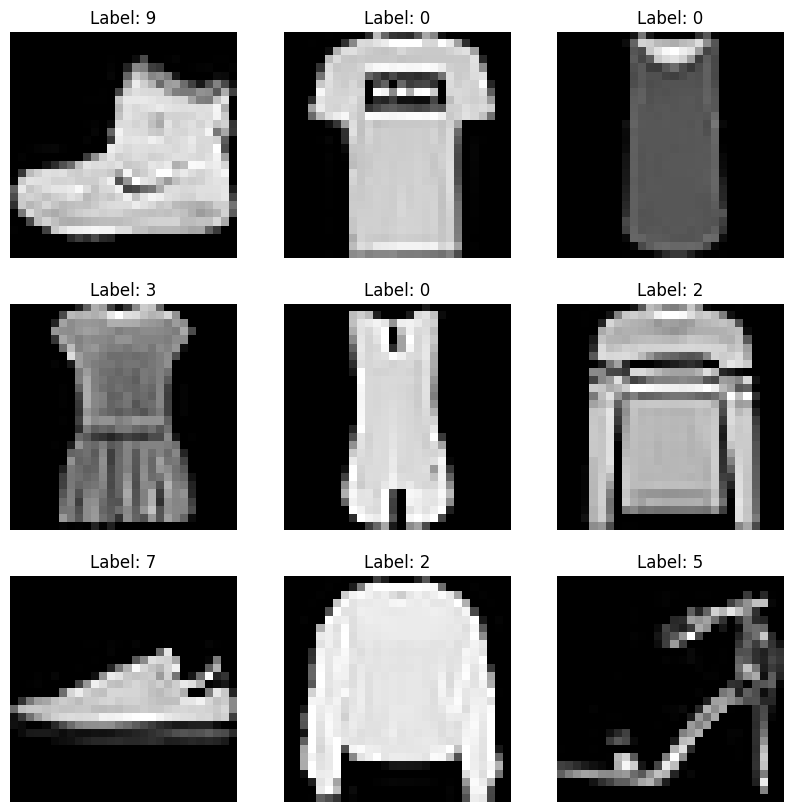

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Cargar el dataset de Fashion MNIST
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalizar los valores de píxeles a un rango de 0 a 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Remodelar las imágenes para que sean 4D (28x28x1) porque son imágenes en escala de grises
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# Convertir las etiquetas a formato one-hot encoding
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Visualizar algunas imágenes para entender el dataset
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {train_labels[i].argmax()}')
    plt.axis('off')
plt.show()


In [28]:
# Construcción de la red neuronal convolucional (CNN)
model = models.Sequential()

# Capa de convolución con 32 filtros, tamaño 3x3, y función de activación ReLU
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Capa de max pooling con tamaño 2x2
model.add(layers.MaxPooling2D((2, 2)))

# Segunda capa de convolución
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Capa de max pooling
model.add(layers.MaxPooling2D((2, 2)))

# Capa de convolución adicional para mayor profundidad
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Aplanar las salidas para conectarlas a la capa densa
model.add(layers.Flatten())

# Capa densa con 64 neuronas
model.add(layers.Dense(64, activation='relu'))

# Capa de salida con 10 neuronas (una por cada clase) y softmax para clasificación multi-clase
model.add(layers.Dense(10, activation='softmax'))

# Resumen de la arquitectura del modelo
model.summary()


C:\Users\Joseph\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compilación del modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento del modelo
history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_data=(test_images, test_labels))

# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'Precisión del modelo en el conjunto de prueba: {test_acc * 100:.2f}%')


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.7293 - loss: 0.7726 - val_accuracy: 0.8538 - val_loss: 0.3924
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8719 - loss: 0.3538 - val_accuracy: 0.8845 - val_loss: 0.3229
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8952 - loss: 0.2877 - val_accuracy: 0.8900 - val_loss: 0.3029
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9036 - loss: 0.2631 - val_accuracy: 0.8938 - val_loss: 0.2969
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9155 - loss: 0.2291 - val_accuracy: 0.9055 - val_loss: 0.2630
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.9221 - loss: 0.2120 - val_accuracy: 0.9049 - val_loss: 0.2701
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9279 - loss: 0.1942 - val_accuracy: 0.9019 - val_loss: 0.2762
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9340 - loss: 0.1809 - 

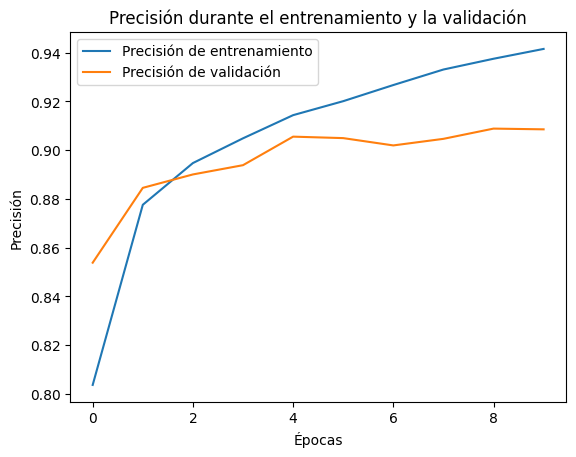

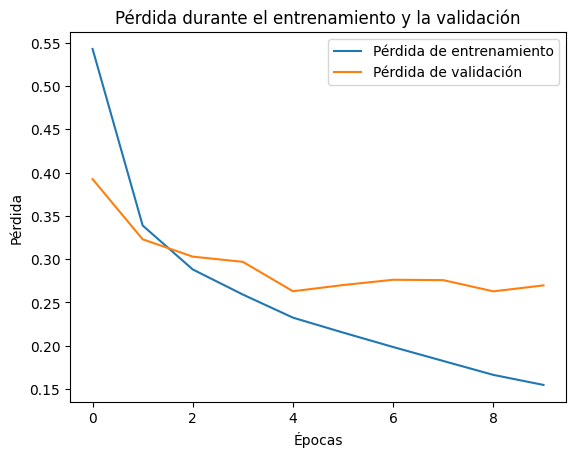

In [32]:
# Graficar la precisión durante el entrenamiento
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento y la validación')
plt.show()

# Graficar la pérdida durante el entrenamiento
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida durante el entrenamiento y la validación')
plt.show()


#### He entrenado una red neuronal convolucional utilizando el conjunto de datos Fashion MNIST, logrando una precisión del 90.85% en el conjunto de prueba después de 10 épocas de entrenamiento. El modelo mostró una mejora consistente a lo largo del proceso, comenzando con una precisión de 72.93% en la primera época y alcanzando un rendimiento sólido en la última. Este buen desempeño sugiere que la red está aprendiendo a clasificar correctamente las imágenes de prendas de ropa, sin sobreajustarse demasiado al conjunto de entrenamiento. A pesar de los buenos resultados, todavía hay espacio para mejorar, por ejemplo, aumentando las épocas de entrenamiento, ajustando algunos hiperparámetros, o aplicando técnicas de regularización como el dropout. En resumen, el modelo se desempeñó bastante bien, y con algunos ajustes adicionales podría ser aún más preciso.